<a href="https://colab.research.google.com/github/rozario-lamperouge/Machine-Learning-Course/blob/master/Ensemble_Learning/XGBoost_and_Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost & Gradient Boosting
### A hands-on 2-hour workshop

> **The core idea in one line:** instead of averaging many independent models, build them **one at a time**,
> where each new model is a small step **downhill on the loss surface** — fitting what the current
> ensemble still gets wrong.

*(Continues from **Notebook 1 — Ensemble Learning Methods**, but is self-contained: you only need to
know what a decision tree is.)*

---


## How to use this notebook
- Run cells **top to bottom** (`Shift + Enter`).
- 🧪 = experiment: change a number, re-run, watch the plot move.
- 💡 = the takeaway to write down.
- ⚠️ = a mistake people actually make in production.

**Datasets (all open source, downloaded automatically):**
1. *Telco Customer Churn* (IBM sample dataset, public GitHub mirror) — 7,043 customers, mixed types, imbalanced.
2. *Wine Quality — red* (UCI ML Repository) — regression.
3. Synthetic 1-D data for the from-scratch section, because you can only *see* an algorithm in 1-D.

---
# 0. Setup

In [1]:
# Colab ships with xgboost. If not present (or you want the latest), uncomment:
# !pip install -q xgboost

import warnings, time, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sklearn
import xgboost as xgb

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
sns.set_palette("Set2")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("sklearn :", sklearn.__version__)
print("xgboost :", xgb.__version__)
print("\nSetup complete.")

sklearn : 1.6.1
xgboost : 3.3.0

Setup complete.


---
# 1. Boosting recap: an additive model

A boosted model is nothing more than a **sum of small models**:

$$F_M(x) = F_0(x) + \nu\, h_1(x) + \nu\, h_2(x) + \dots + \nu\, h_M(x) = F_0(x) + \nu \sum_{m=1}^{M} h_m(x)$$

- $F_0$ — a constant starting guess (the mean for regression, the log-odds for classification)
- $h_m$ — a **weak learner**, almost always a shallow regression tree (depth 3–8)
- $\nu$ — the **learning rate** (`eta`), typically 0.01–0.3. It shrinks every step.

Each $h_m$ is fitted to the **errors the ensemble is still making**. That single sentence is the algorithm.

### AdaBoost vs Gradient Boosting

Both are boosting. They differ in *how* "focus on the errors" is expressed:

| | AdaBoost (1997) | Gradient Boosting (Friedman, 2001) |
|---|---|---|
| Mechanism | **re-weight the rows** that were misclassified | **re-target**: fit the next tree to the *negative gradient* of the loss |
| Loss | exponential loss (fixed) | **any differentiable loss** — squared, absolute, logistic, Poisson, ranking, quantile... |
| Generality | classification-first | one framework for regression, classification, ranking, survival |

Gradient boosting's flexibility is why it took over. Let's build it.

---
# 2. Gradient boosting from scratch

For **squared error** loss, the negative gradient is simply the **residual**:

$$L = \tfrac{1}{2}(y - F(x))^2 \quad\Longrightarrow\quad -\frac{\partial L}{\partial F} = y - F(x)$$

So the whole algorithm collapses to:

```
F = mean(y)                       # F0
repeat M times:
    r = y - F                     # what we still get wrong
    h = DecisionTree().fit(X, r)  # learn the pattern in the errors
    F = F + lr * h.predict(X)     # take a small step
```

That is it. **Nine lines.** Let's run it and watch each stage.

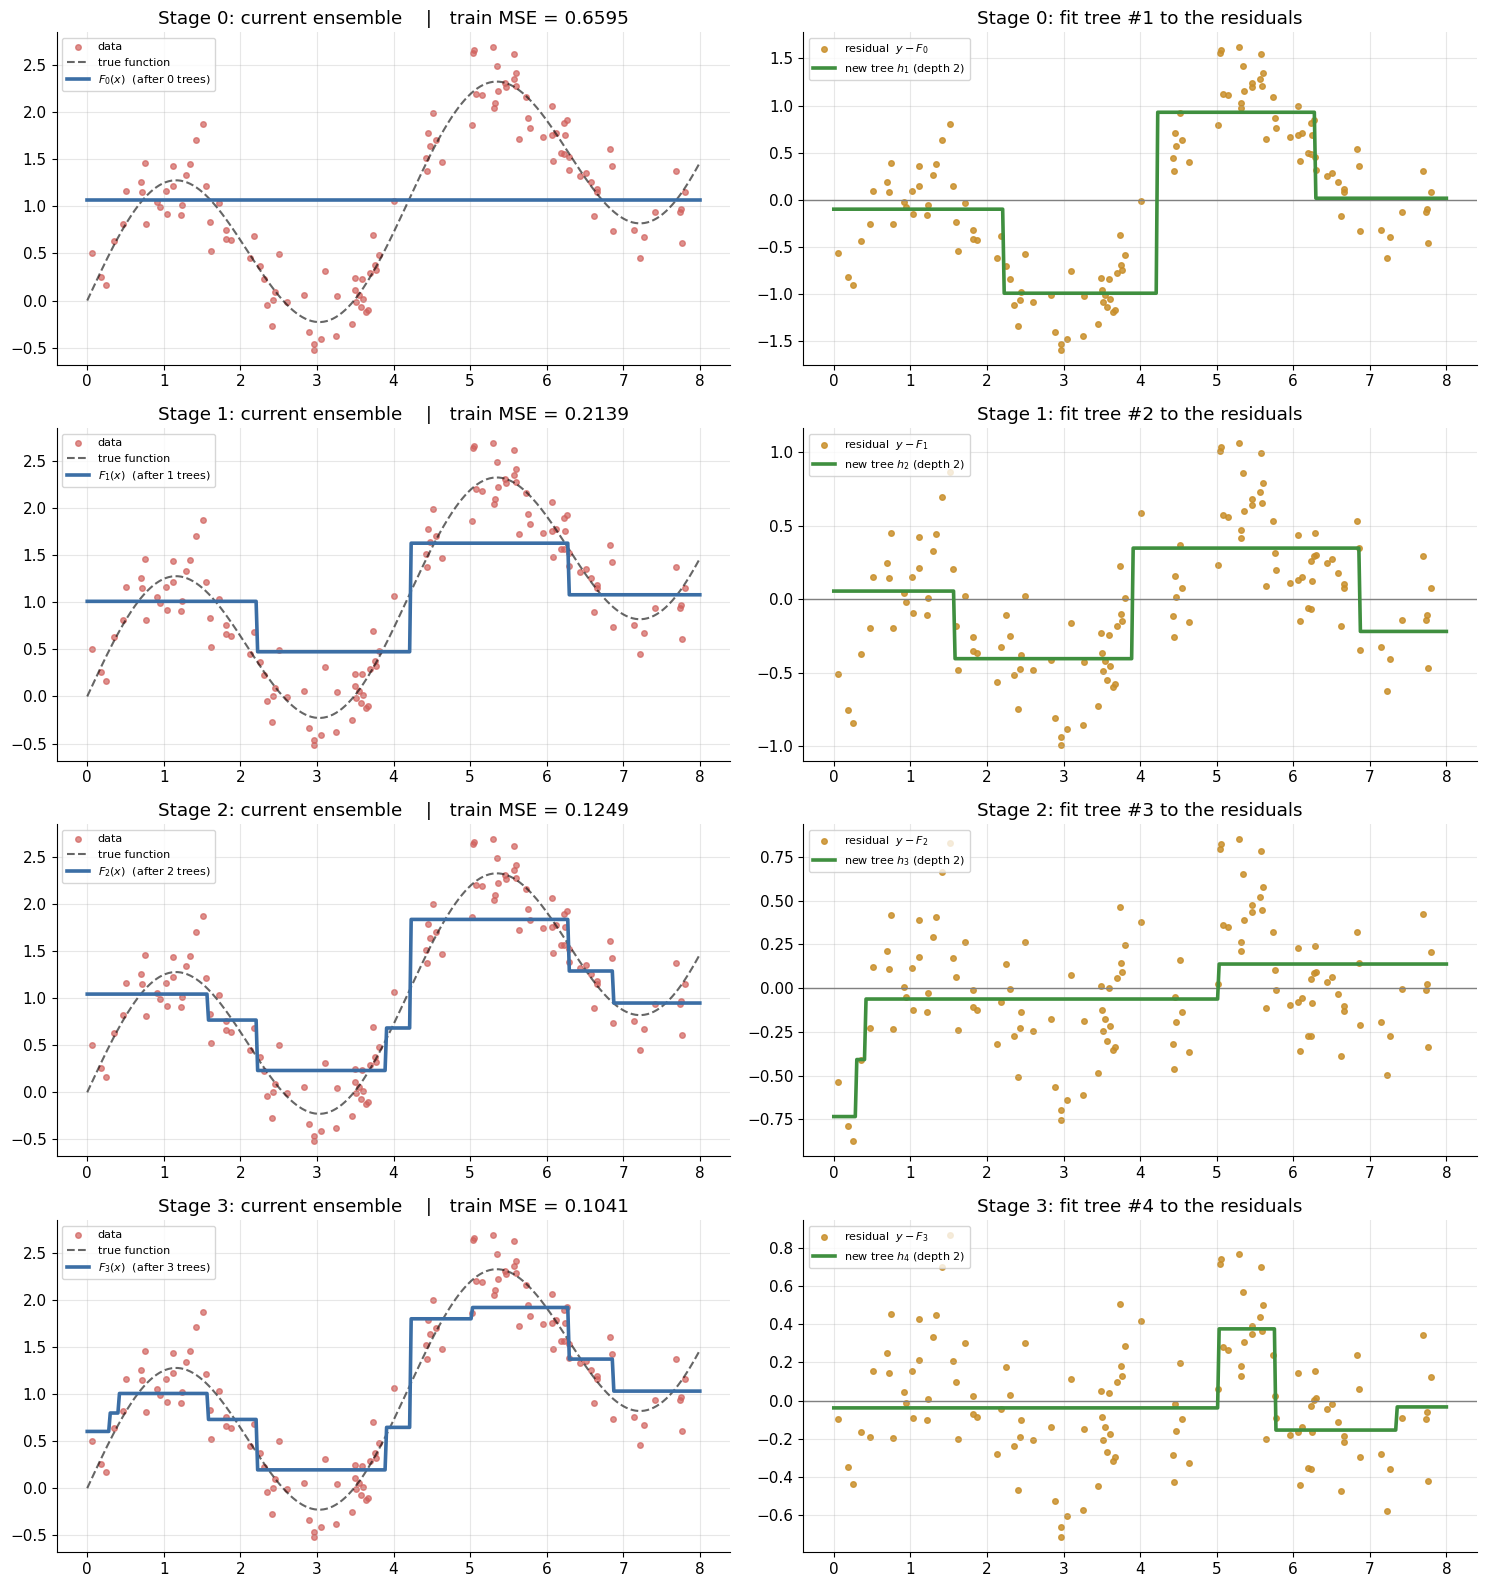

Train MSE by stage: [0.6595 0.2139 0.1249 0.1041 0.0815]


In [2]:
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(RANDOM_STATE)
def true_f(x): return np.sin(1.5 * x) + 0.25 * x

x = np.sort(rng.uniform(0, 8, 120)).reshape(-1, 1)
y = true_f(x).ravel() + rng.normal(0, 0.25, 120)
x_line = np.linspace(0, 8, 400).reshape(-1, 1)

LR, DEPTH, STAGES = 0.6, 2, 4

F = np.full(len(y), y.mean())          # F0: the constant model
F_line = np.full(len(x_line), y.mean())
trees, mse_history = [], [np.mean((y - F) ** 2)]

fig, axes = plt.subplots(STAGES, 2, figsize=(15, 4 * STAGES))
for m in range(STAGES):
    residual = y - F                                        # <-- pseudo-residual
    h = DecisionTreeRegressor(max_depth=DEPTH, random_state=RANDOM_STATE).fit(x, residual)
    trees.append(h)

    # LEFT: the ensemble so far vs the data
    ax = axes[m, 0]
    ax.scatter(x, y, s=16, color="#d1615d", alpha=0.7, label="data")
    ax.plot(x_line, true_f(x_line), "k--", lw=1.5, alpha=0.6, label="true function")
    ax.plot(x_line, F_line, color="#3b6ea5", lw=2.6, label=f"$F_{m}(x)$  (after {m} trees)")
    ax.set_title(f"Stage {m}: current ensemble    |   train MSE = {np.mean((y-F)**2):.4f}")
    ax.legend(fontsize=8, loc="upper left")

    # RIGHT: the residuals and the tree we fit to them
    ax = axes[m, 1]
    ax.axhline(0, color="grey", lw=1)
    ax.scatter(x, residual, s=16, color="#c98f2b", alpha=0.85, label="residual  $y - F_{%d}$" % m)
    ax.plot(x_line, h.predict(x_line), color="#3f8f3f", lw=2.6,
            label=f"new tree $h_{m+1}$ (depth {DEPTH})")
    ax.set_title(f"Stage {m}: fit tree #{m+1} to the residuals")
    ax.legend(fontsize=8, loc="upper left")

    F = F + LR * h.predict(x)                               # <-- the boosting step
    F_line = F_line + LR * h.predict(x_line)
    mse_history.append(np.mean((y - F) ** 2))

plt.tight_layout(); plt.show()
print("Train MSE by stage:", np.round(mse_history, 4))

Look at the right-hand column: at stage 0 the residuals are a clean sine wave — **all the signal is
still sitting in the errors**. By stage 3 they are much closer to structureless noise. Boosting is
finished when the residuals contain nothing learnable.

## 2.1 Push it to 100 trees and check against scikit-learn

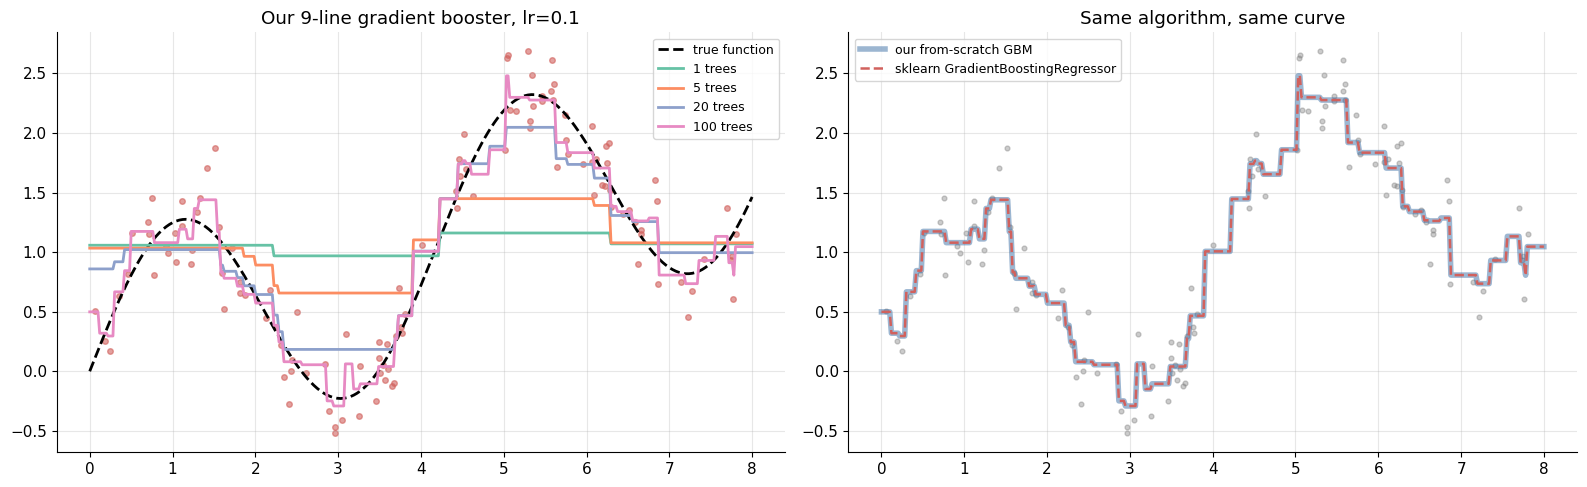

Max absolute difference between the two: 0.000000


In [3]:
def manual_gbm(x, y, x_eval, n_trees=100, lr=0.1, depth=2, seed=RANDOM_STATE):
    F, F_eval = np.full(len(y), y.mean()), np.full(len(x_eval), y.mean())
    curves = {}
    for m in range(1, n_trees + 1):
        h = DecisionTreeRegressor(max_depth=depth, random_state=seed).fit(x, y - F)
        F      += lr * h.predict(x)
        F_eval += lr * h.predict(x_eval)
        if m in (1, 5, 20, 100):
            curves[m] = F_eval.copy()
    return F_eval, curves

_, curves = manual_gbm(x, y, x_line, n_trees=100, lr=0.1, depth=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(x, y, s=16, color="#d1615d", alpha=0.6)
axes[0].plot(x_line, true_f(x_line), "k--", lw=2, label="true function")
for m, c in curves.items():
    axes[0].plot(x_line, c, lw=2, label=f"{m} trees")
axes[0].set_title("Our 9-line gradient booster, lr=0.1"); axes[0].legend(fontsize=9)

# sanity check against sklearn
from sklearn.ensemble import GradientBoostingRegressor
sk = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2,
                               random_state=RANDOM_STATE).fit(x, y)
mine, _ = manual_gbm(x, y, x_line, 100, 0.1, 2)
axes[1].plot(x_line, mine, lw=4, alpha=0.5, color="#3b6ea5", label="our from-scratch GBM")
axes[1].plot(x_line, sk.predict(x_line), lw=1.8, color="#d1615d", ls="--",
             label="sklearn GradientBoostingRegressor")
axes[1].scatter(x, y, s=12, color="grey", alpha=0.4)
axes[1].set_title("Same algorithm, same curve"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Max absolute difference between the two: {np.max(np.abs(mine - sk.predict(x_line))):.6f}")

💡 **Takeaway 1:** gradient boosting is not magic. It is *fit the errors, take a small step, repeat*.
Everything else — XGBoost, LightGBM, CatBoost — is **engineering and regularisation on top of this loop**.

---
# 3. The maths: gradient descent in function space

Ordinary gradient descent updates **parameters**:
$\;\theta_{t+1} = \theta_t - \nu \nabla_\theta L$

Gradient boosting updates the **function itself**:
$\;F_{m}(x) = F_{m-1}(x) - \nu \frac{\partial L}{\partial F_{m-1}}$

We cannot store an arbitrary function, so we **approximate the gradient with a tree**:

$$h_m = \arg\min_h \sum_i \left( \underbrace{-\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}}_{\text{pseudo-residual } r_{im}} - h(x_i) \right)^2$$

**The loss determines what "the errors" means.** That is the entire source of gradient boosting's flexibility:

| Task | Loss | Pseudo-residual $-\partial L/\partial F$ | XGBoost `objective` |
|---|---|---|---|
| Regression | squared error | $y - F$ | `reg:squarederror` |
| Robust regression | absolute error | $\text{sign}(y - F)$ | `reg:absoluteerror` |
| Binary classification | logistic / log-loss | $y - \sigma(F)$ | `binary:logistic` |
| Multiclass | softmax | $y_k - p_k$ | `multi:softprob` |
| Counts | Poisson | $y - e^{F}$ | `count:poisson` |
| Ranking | pairwise / LambdaMART | — | `rank:pairwise` |
| Quantile / prediction intervals | pinball | asymmetric sign | `reg:quantileerror` |

⚠️ For classification, $F(x)$ lives in **log-odds space**, not probability space. The residual is
$y - \sigma(F)$: a confidently-correct point contributes ≈ 0 and is effectively ignored,
which is why boosting spends its later rounds on the hard examples.

---
# 4. Learning rate, depth, and shrinkage

The learning rate $\nu$ and the number of trees $M$ are **coupled**: halve the learning rate and you
need roughly twice the trees. Low $\nu$ + many trees generalises better — that is *shrinkage*
regularisation — but costs compute.

The rule of thumb used by practically everyone:

> **Fix `learning_rate` at 0.05–0.1, then use early stopping to choose `n_estimators`.**

---
# 5. The real dataset: Telco customer churn

**IBM Telco Customer Churn** — 7,043 customers of a telecom company.
Predict `Churn` (did the customer leave?) from contract type, tenure, services, billing, etc.

Why this dataset is a good teaching example — it has every problem you meet at work:
- **Mixed types**: 16 categorical + 3 numeric columns
- **A dirty column**: `TotalCharges` is stored as text with blank strings
- **Class imbalance**: ~26.5% churn
- **Business context**: false negatives (missed churners) cost far more than false positives, so
  accuracy is the *wrong* metric and the decision threshold matters

In [12]:
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
telco = pd.read_csv(URL)
print("Raw shape:", telco.shape)

telco.head()

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# --- cleaning ---------------------------------------------------------------
telco = telco.drop(columns=["customerID"])

In [14]:
# TotalCharges arrives as object because 11 brand-new customers have a blank string
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")
print("Blank TotalCharges rows:", telco["TotalCharges"].isna().sum(),
      "-> all of them have tenure =", telco.loc[telco['TotalCharges'].isna(), 'tenure'].unique())

Blank TotalCharges rows: 11 -> all of them have tenure = [0]


In [15]:
telco["Churn"] = (telco["Churn"] == "Yes").astype(int)
telco["SeniorCitizen"] = telco["SeniorCitizen"].astype(str)   # it is a flag, not a number

print("\nChurn rate:", f"{telco['Churn'].mean():.1%}")
telco.head()


Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


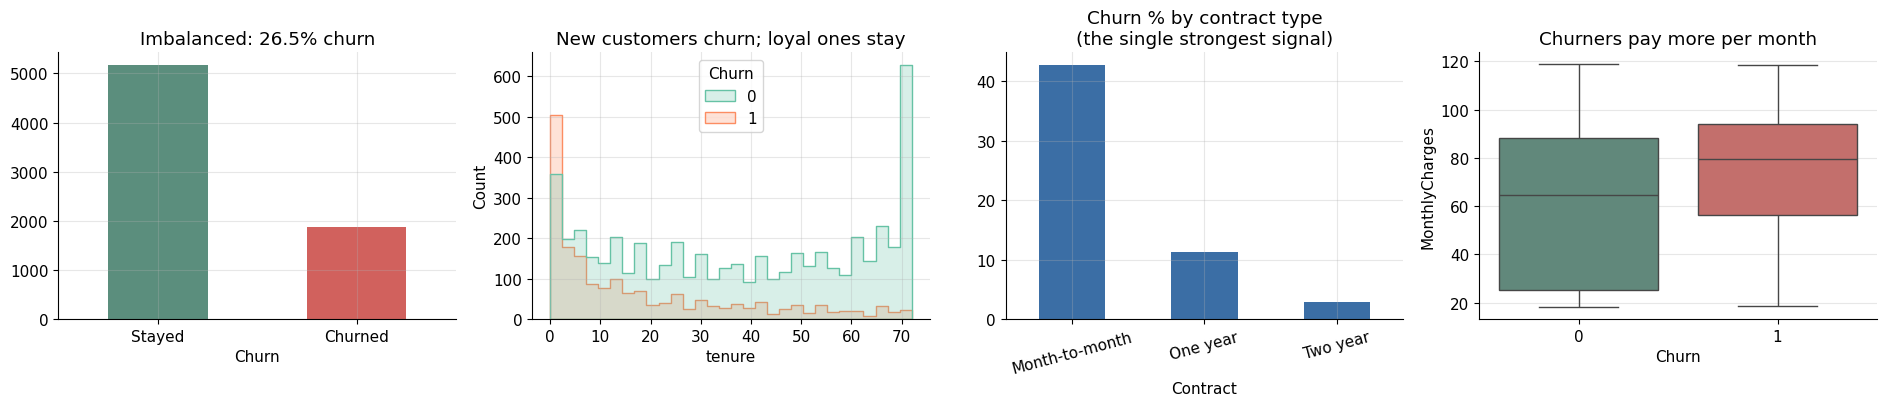

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))

telco["Churn"].map({0: "Stayed", 1: "Churned"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#5b8e7d", "#d1615d"], rot=0)
axes[0].set_title(f"Imbalanced: {telco['Churn'].mean():.1%} churn")

sns.histplot(data=telco, x="tenure", hue="Churn", bins=30, element="step", ax=axes[1])
axes[1].set_title("New customers churn; loyal ones stay")

(telco.groupby("Contract")["Churn"].mean() * 100).plot(kind="bar", ax=axes[2],
                                                       color="#3b6ea5", rot=15)
axes[2].set_title("Churn % by contract type\n(the single strongest signal)")

sns.boxplot(data=telco, x="Churn", y="MonthlyCharges", ax=axes[3],
            palette=["#5b8e7d", "#d1615d"])
axes[3].set_title("Churners pay more per month")
plt.tight_layout(); plt.show()

In [17]:
from sklearn.model_selection import train_test_split

y_t = telco["Churn"]
X_t = telco.drop(columns="Churn")

cat_cols = X_t.select_dtypes(include="object").columns.tolist()
num_cols = X_t.select_dtypes(include=np.number).columns.tolist()
print(f"{len(cat_cols)} categorical, {len(num_cols)} numeric")

# One-hot version (what most libraries need). XGBoost can skip this - see Section 10.
X_ohe = pd.get_dummies(X_t, columns=cat_cols, drop_first=False)
print("After one-hot:", X_ohe.shape)

X_tr, X_te, y_tr, y_te = train_test_split(X_ohe, y_t, test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=y_t)
# a validation split carved out of train, used for early stopping
X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.2,
                                              random_state=RANDOM_STATE, stratify=y_tr)
print(f"train {X_tr2.shape[0]} | val {X_val.shape[0]} | test {X_te.shape[0]}")

17 categorical, 3 numeric
After one-hot: (7043, 7089)
train 4507 | val 1127 | test 1409


In [18]:
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             f1_score, recall_score, precision_score,
                             classification_report, confusion_matrix)

RESULTS = {}

def evaluate(model, name, Xtr=X_tr, ytr=y_tr, Xte=X_te, yte=y_te, fit_kwargs=None, store=True):
    t0 = time.time()
    model.fit(Xtr, ytr, **(fit_kwargs or {}))
    secs = time.time() - t0
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    row = {"accuracy": accuracy_score(yte, pred),
           "roc_auc": roc_auc_score(yte, proba),
           "pr_auc": average_precision_score(yte, proba),
           "recall": recall_score(yte, pred),
           "f1": f1_score(yte, pred),
           "fit_s": secs}
    if store: RESULTS[name] = row
    print(f"{name:<34} acc={row['accuracy']:.4f}  auc={row['roc_auc']:.4f}  "
          f"pr_auc={row['pr_auc']:.4f}  recall={row['recall']:.4f}  {secs:.2f}s")
    return model

### Baselines first — always
Never report a boosting score without a dumb baseline and a linear model next to it.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

evaluate(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE), "Dummy (stratified)")
evaluate(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                       LogisticRegression(max_iter=3000)), "Logistic Regression")
evaluate(make_pipeline(SimpleImputer(strategy="median"),
                       RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                              n_jobs=-1, random_state=RANDOM_STATE)),
         "Random Forest (400)")
evaluate(make_pipeline(SimpleImputer(strategy="median"),
                       GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                  max_depth=3, random_state=RANDOM_STATE)),
         "sklearn GradientBoosting (200)")

Dummy (stratified)                 acc=0.6217  auc=0.5163  pr_auc=0.2723  recall=0.2914  0.00s
Logistic Regression                acc=0.7928  auc=0.8298  pr_auc=0.6118  recall=0.4091  7.45s
Random Forest (400)                acc=0.7346  auc=0.8183  pr_auc=0.6030  recall=0.0000  14.09s
sklearn GradientBoosting (200)     acc=0.8055  auc=0.8462  pr_auc=0.6610  recall=0.5134  97.05s


Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

Note we had to wrap everything in `SimpleImputer` because of those 11 missing `TotalCharges` values.
**XGBoost will not need it** — missing values are a first-class citizen. That is our first
concrete advantage.

---
# 6. What XGBoost actually changed

XGBoost (Chen & Guestrin, 2016) is gradient boosting with **five** significant upgrades:

### 6.1 A regularised objective
Classic GBM minimises the loss. XGBoost minimises loss **plus an explicit penalty on tree complexity**:

$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_m \Omega(h_m), \qquad
\Omega(h) = \underbrace{\gamma T}_{\text{cost per leaf}} + \underbrace{\tfrac{1}{2}\lambda \sum_{j=1}^{T} w_j^2}_{\text{L2 on leaf values}}$$

Regularisation is **inside the split-finding criterion**, not bolted on afterwards.

### 6.2 Second-order optimisation (Newton boosting)
Classic GBM uses only the gradient $g_i$. XGBoost also uses the second derivative (hessian) $h_i$,
Taylor-expanding the loss to second order. This gives a **closed-form optimal leaf weight**:

$$w_j^* = -\frac{\sum_{i \in j} g_i}{\sum_{i \in j} h_i + \lambda}
\qquad\text{and score}\qquad
\text{Similarity}_j = \frac{\left(\sum_{i \in j} g_i\right)^2}{\sum_{i \in j} h_i + \lambda}$$

A split is worth making only if it increases the total similarity by more than $\gamma$:

$$\text{Gain} = \tfrac{1}{2}\left[\text{Sim}_{\text{left}} + \text{Sim}_{\text{right}} - \text{Sim}_{\text{parent}}\right] - \gamma$$

**Negative gain → prune the split.** This is *pre-pruning by mathematics*, not by a `max_depth` guess.

### 6.3 Sparsity-aware split finding
Every split learns a **default direction** for missing values from the data itself.
No imputation, and sparse one-hot matrices are skipped efficiently.

### 6.4 Histogram / approximate split finding
Instead of sorting every feature at every node (exact greedy, $O(n\log n)$ per feature),
bucket features into ~256 bins once and scan the bins. Near-identical accuracy, an order of magnitude faster.

### 6.5 Systems engineering
Cache-aware block structure, out-of-core computation, multi-threading, GPU support, distributed training.
*This*, more than the maths, is why XGBoost won Kaggle in 2015–2017.

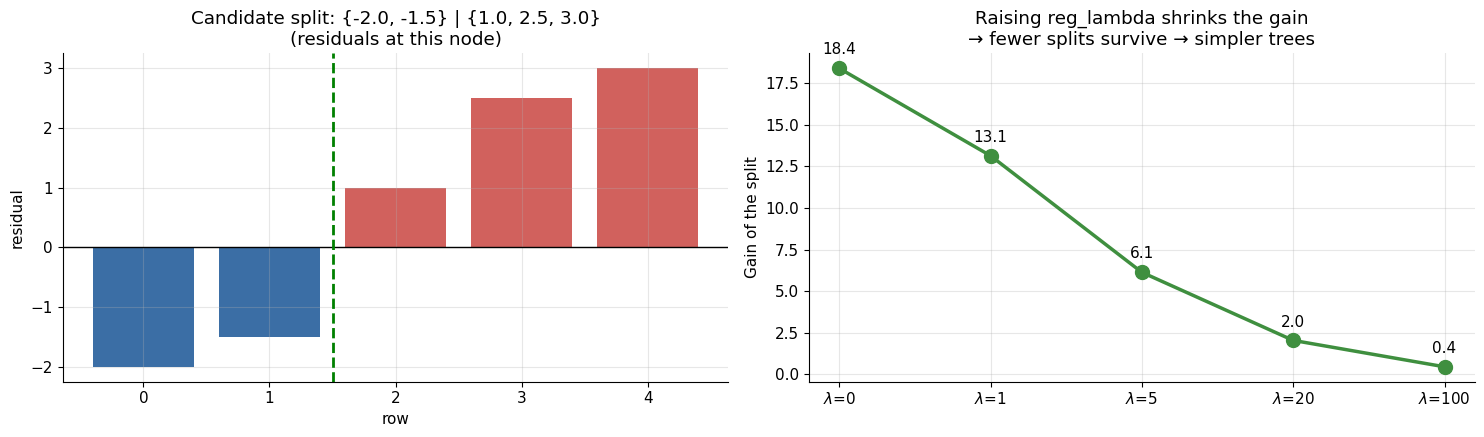

Optimal leaf weights (lambda=1): [ 1.167 -1.625]

With gamma set above the gain, XGBoost simply refuses to make this split.


In [15]:
# A worked example of the gain formula. Squared-error loss -> g = (pred - y), h = 1.
residuals = np.array([-2.0, -1.5, 1.0, 2.5, 3.0])     # residuals of 5 rows at some node
def similarity(r, lam):  return r.sum() ** 2 / (len(r) + lam)

lams = [0, 1, 5, 20, 100]
left, right = residuals[:2], residuals[2:]            # a candidate split
gains = []
for lam in lams:
    gain = similarity(left, lam) + similarity(right, lam) - similarity(residuals, lam)
    gains.append(gain)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(range(5), residuals, color=["#3b6ea5"]*2 + ["#d1615d"]*3)
axes[0].axhline(0, color="k", lw=1)
axes[0].axvline(1.5, color="green", ls="--", lw=2)
axes[0].set_title("Candidate split: {-2.0, -1.5} | {1.0, 2.5, 3.0}\n(residuals at this node)")
axes[0].set_xlabel("row"); axes[0].set_ylabel("residual")

axes[1].plot(range(len(lams)), gains, "o-", lw=2.5, color="#3f8f3f", ms=10)
axes[1].set_xticks(range(len(lams))); axes[1].set_xticklabels([f"$\\lambda$={l}" for l in lams])
axes[1].set_ylabel("Gain of the split")
axes[1].set_title("Raising reg_lambda shrinks the gain\n→ fewer splits survive → simpler trees")
for i, g in enumerate(gains):
    axes[1].annotate(f"{g:.1f}", (i, g), textcoords="offset points", xytext=(0, 10), ha="center")
plt.tight_layout(); plt.show()

print("Optimal leaf weights (lambda=1):",
      np.round([-left.sum()/(len(left)+1), -right.sum()/(len(right)+1)], 3))
print("\nWith gamma set above the gain, XGBoost simply refuses to make this split.")

## 6.6 XGBoost on the churn data
Two APIs, same engine:

| API | Looks like | Use when |
|---|---|---|
| **scikit-learn API** — `XGBClassifier` | `.fit()` / `.predict()` | you want pipelines, `GridSearchCV`, familiarity ✅ |
| **native API** — `xgb.train` + `DMatrix` | booster objects, param dicts | you want `xgb.cv`, custom objectives, maximum control |

We use the sklearn API throughout and show the native one in Section 11.

Hyperparameters:

- **n_estimators=300:** The number of boosting rounds (trees) to build.
- **learning_rate=0.1**: The step size shrinkage used in update to prevents overfitting.
- **max_depth=5**: The maximum depth of each individual tree.
- **subsample & colsample_bytree**: These add randomness by sampling 80% of rows and columns for each tree, which helps the model generalize.
- **reg_lambda=1.0**: L2 regularization term on weights, making the model more conservative.
- **objective="binary:logistic"**: This specifies that we are doing binary classification and want output probabilities
- **tree_method="hist"**: This uses a fast histogram-based algorithm for building trees, which is much more efficient than the exact greedy method.


In [20]:
from xgboost import XGBClassifier

xgb_base = evaluate(
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",     # default since 2.0; stated here for clarity
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost (300, untuned)",
)

# note: no imputer in the pipeline - XGBoost handled the NaNs itself
print("\nNaNs passed straight to XGBoost:", int(X_tr.isna().sum().sum()))

XGBoost (300, untuned)             acc=0.7984  auc=0.8273  pr_auc=0.6280  recall=0.5455  46.31s

NaNs passed straight to XGBoost: 8


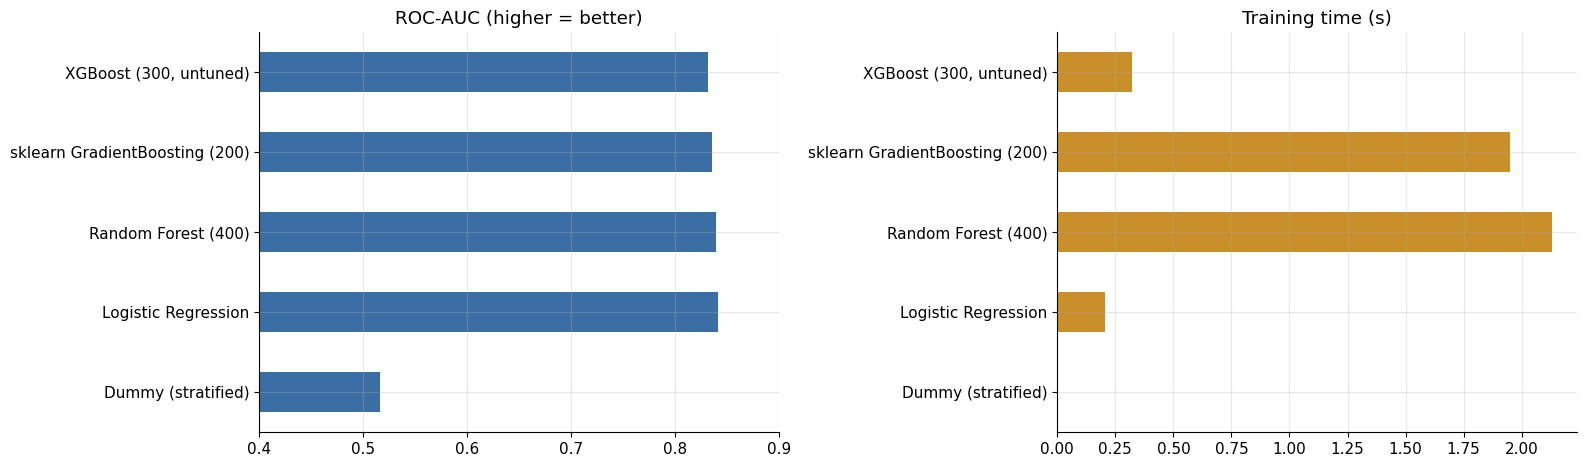

,accuracy,roc_auc,pr_auc,recall,f1,fit_s
Dummy (stratified),0.6217,0.5163,0.2723,0.2914,0.2903,0.0014
Logistic Regression,0.8070,0.8416,0.6311,0.5668,0.6092,0.2050
Random Forest (400),0.7970,0.8397,0.6470,0.5053,0.5693,2.1316
sklearn GradientBoosting (200),0.7885,0.8354,0.6481,0.5027,0.5579,1.9496
"XGBoost (300, untuned)",0.7949,0.8315,0.6336,0.5401,0.5830,0.3236


In [ ]:
comp = pd.DataFrame(RESULTS).T
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
comp["roc_auc"].plot(kind="barh", ax=axes[0], color="#3b6ea5")
axes[0].set_xlim(0.4, 0.9); axes[0].set_title("ROC-AUC (higher = better)")
comp["fit_s"].plot(kind="barh", ax=axes[1], color="#c98f2b")
axes[1].set_title("Training time (s)")
plt.tight_layout(); plt.show()
comp.round(4)

---
# 7. Early stopping — the feature you will use every single day

Section 4 showed boosting has a **best** number of rounds. Early stopping finds it automatically:
train on `X_tr2`, watch the metric on `X_val`, and stop when it has not improved for
`early_stopping_rounds` iterations. XGBoost then keeps the **best** iteration.

⚠️ The validation set must be **separate from the test set**. Early stopping *is* model selection —
choosing rounds on the test set leaks and inflates your reported score.

n_estimators requested : 2000
best_iteration found   : 45
best validation score  : 0.84997


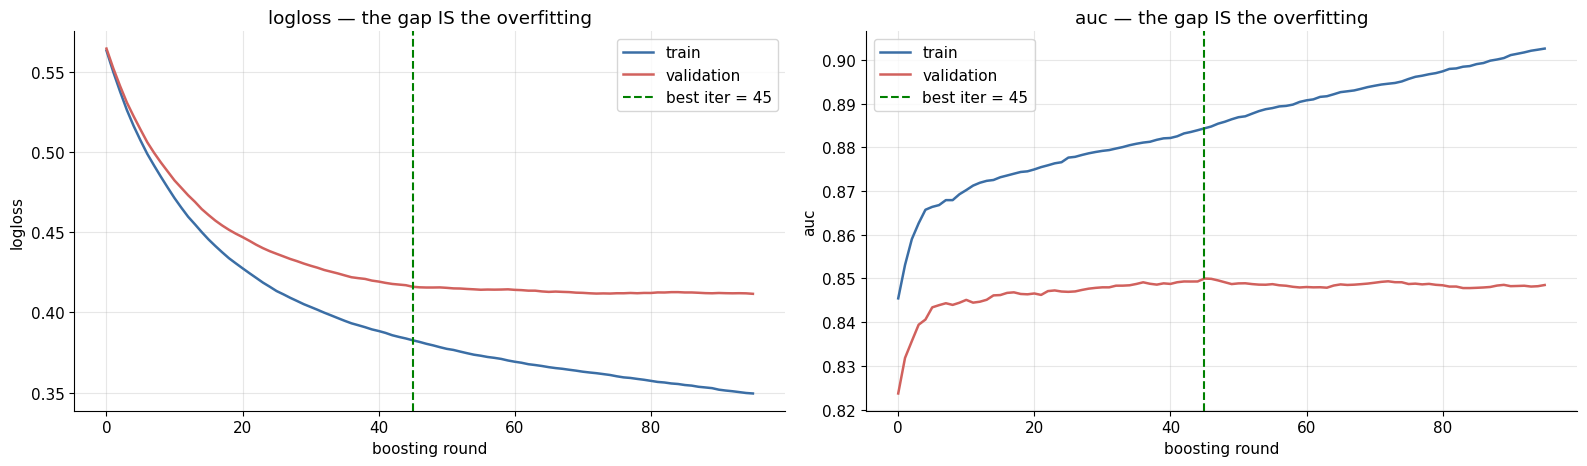

XGBoost + early stopping           acc=0.7977  auc=0.8452  pr_auc=0.6539  recall=0.4519  0.21s


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [ ]:
es_model = XGBClassifier(
    n_estimators=2000,                 # deliberately far too many
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["logloss", "auc"],
    early_stopping_rounds=50,          # set in the CONSTRUCTOR (xgboost >= 1.6)
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
es_model.fit(X_tr2, y_tr2, eval_set=[(X_tr2, y_tr2), (X_val, y_val)], verbose=False)

print(f"n_estimators requested : 2000")
print(f"best_iteration found   : {es_model.best_iteration}")
print(f"best validation score  : {es_model.best_score:.5f}")

hist = es_model.evals_result()
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for ax, metric in zip(axes, ["logloss", "auc"]):
    ax.plot(hist["validation_0"][metric], label="train", color="#3b6ea5", lw=1.8)
    ax.plot(hist["validation_1"][metric], label="validation", color="#d1615d", lw=1.8)
    ax.axvline(es_model.best_iteration, color="green", ls="--",
               label=f"best iter = {es_model.best_iteration}")
    ax.set_xlabel("boosting round"); ax.set_ylabel(metric)
    ax.set_title(f"{metric} — the gap IS the overfitting")
    ax.legend()
plt.tight_layout(); plt.show()

evaluate(es_model, "XGBoost + early stopping", Xtr=X_tr2, ytr=y_tr2,
         fit_kwargs={"eval_set": [(X_val, y_val)], "verbose": False})

---
# 8. The hyper-parameter tour

There are ~30 knobs. In practice you touch **eight**. Group them by what they control:

### Complexity of each tree (how much each tree can memorise)
| Param | Default | Range | Effect |
|---|---|---|---|
| `max_depth` | 6 | 3–10 | ↑ = more interactions captured, exponentially more leaves, overfits fast |
| `min_child_weight` | 1 | 1–20 | minimum sum of hessians in a leaf. ↑ = more conservative |
| `gamma` (`min_split_loss`) | 0 | 0–5 | minimum gain to make a split. ↑ = aggressive pruning |

### Randomness (the "bagging inside boosting" trick)
| Param | Default | Range | Effect |
|---|---|---|---|
| `subsample` | 1.0 | 0.5–1.0 | fraction of **rows** per tree |
| `colsample_bytree` | 1.0 | 0.5–1.0 | fraction of **columns** per tree |
| `colsample_bylevel` / `bynode` | 1.0 | 0.5–1.0 | finer-grained column sampling |

### Shrinkage & explicit regularisation
| Param | Default | Range | Effect |
|---|---|---|---|
| `learning_rate` (`eta`) | 0.3 | 0.01–0.3 | step size. ↓ = better, slower |
| `n_estimators` | 100 | 100–5000 | let **early stopping** decide |
| `reg_lambda` | 1 | 0–100 | L2 on leaf weights (smooths) |
| `reg_alpha` | 0 | 0–10 | L1 on leaf weights (sparsifies) |

### 💡 A sane starting recipe for tabular data
```python
XGBClassifier(n_estimators=2000, learning_rate=0.05, max_depth=5,
              min_child_weight=2, subsample=0.8, colsample_bytree=0.8,
              reg_lambda=1.0, early_stopping_rounds=50)
```
Now let's *see* each knob move the validation curve.

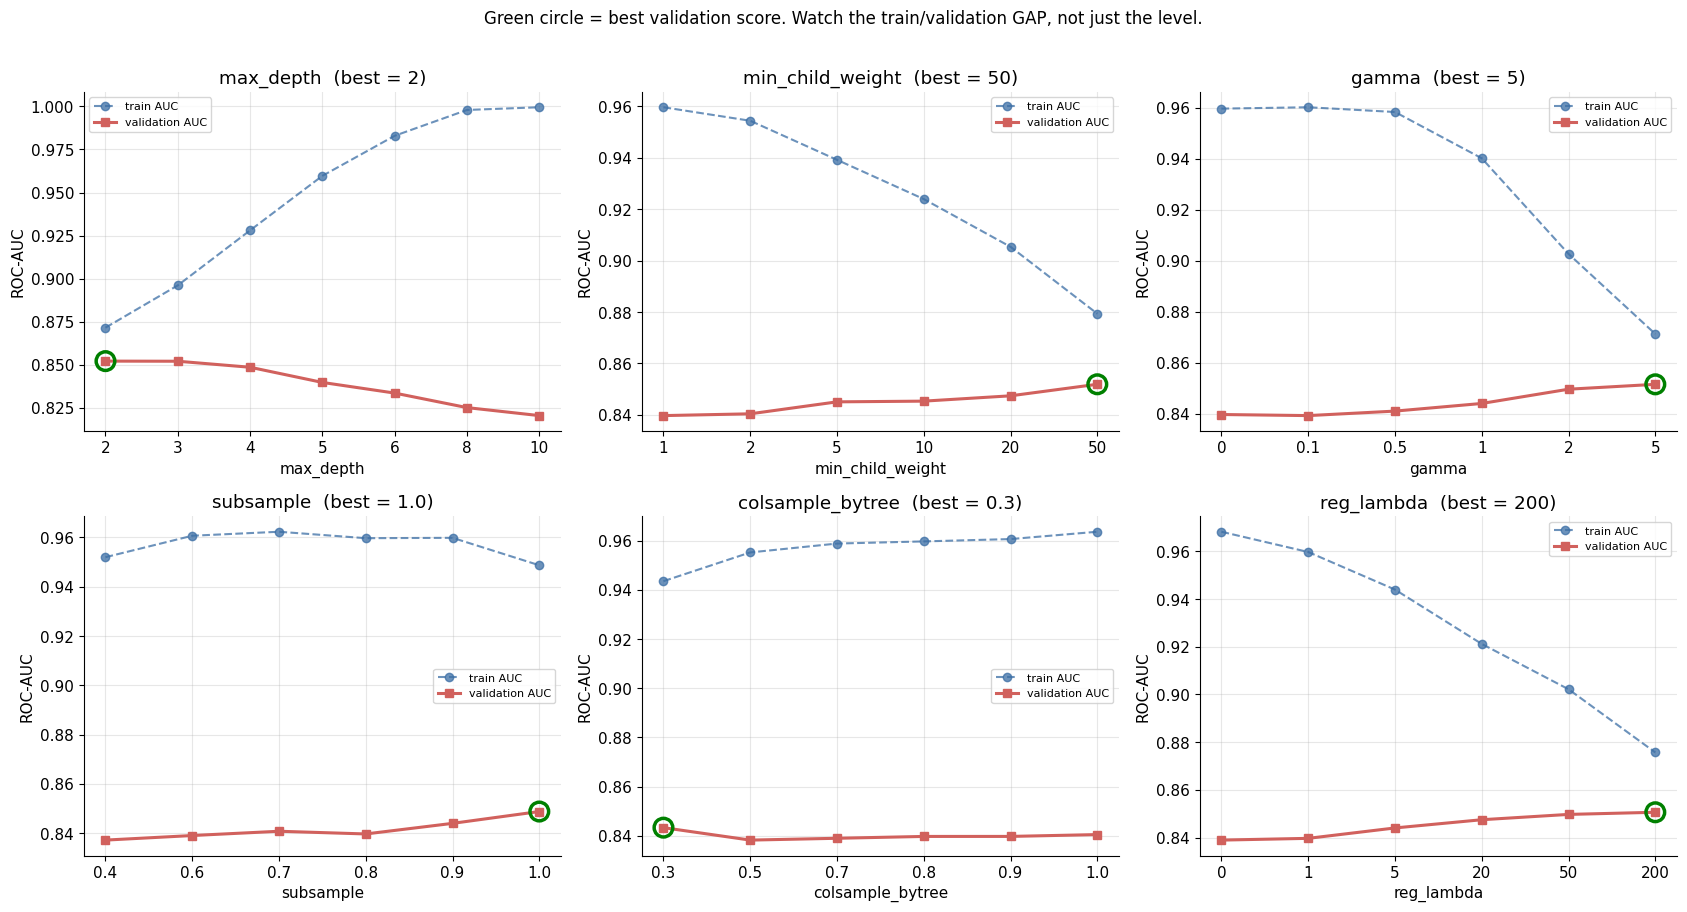

In [ ]:
def sweep(param, values, fixed=None):
    fixed = {**dict(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, eval_metric="auc", n_jobs=-1,
                    random_state=RANDOM_STATE), **(fixed or {})}
    tr_s, va_s = [], []
    for v in values:
        p = {**fixed, param: v}
        m = XGBClassifier(**p).fit(X_tr2, y_tr2)
        tr_s.append(roc_auc_score(y_tr2, m.predict_proba(X_tr2)[:, 1]))
        va_s.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
    return tr_s, va_s

sweeps = [
    ("max_depth",        [2, 3, 4, 5, 6, 8, 10]),
    ("min_child_weight", [1, 2, 5, 10, 20, 50]),
    ("gamma",            [0, 0.1, 0.5, 1, 2, 5]),
    ("subsample",        [0.4, 0.6, 0.7, 0.8, 0.9, 1.0]),
    ("colsample_bytree", [0.3, 0.5, 0.7, 0.8, 0.9, 1.0]),
    ("reg_lambda",       [0, 1, 5, 20, 50, 200]),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (param, vals) in zip(axes.ravel(), sweeps):
    tr_s, va_s = sweep(param, vals)
    ax.plot(range(len(vals)), tr_s, "o--", color="#3b6ea5", label="train AUC", alpha=0.75)
    ax.plot(range(len(vals)), va_s, "s-", color="#d1615d", lw=2.2, label="validation AUC")
    best = int(np.argmax(va_s))
    ax.scatter([best], [va_s[best]], s=180, facecolor="none", edgecolor="green", lw=2.5, zorder=5)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals)
    ax.set_xlabel(param); ax.set_ylabel("ROC-AUC")
    ax.set_title(f"{param}  (best = {vals[best]})")
    ax.legend(fontsize=8)
plt.suptitle("Green circle = best validation score. Watch the train/validation GAP, not just the level.",
             y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

💡 **Takeaway 3:** read these plots as *gap management*. On this dataset `max_depth` above ~4 buys
train AUC and **loses** validation AUC — classic overfitting. Meanwhile `min_child_weight`,
`gamma` and `reg_lambda` all close the gap by making trees more conservative.
They are three different levers on the same idea, which is why you rarely need to tune all three.

---
# 9. Imbalanced targets and the decision threshold

26.5% churn is mild imbalance, but the **business asymmetry is severe**: missing a churner costs
a customer; a false alarm costs one retention email. Two independent tools:

1. **`scale_pos_weight`** — multiply the gradient of positive examples. Rule of thumb:
   `n_negative / n_positive`. This changes what the model *learns*.
2. **Move the decision threshold** — the default 0.5 is an arbitrary convention, not a law.
   This changes how you *use* a model you already trained, and it is usually the better lever.

⚠️ With imbalance, **ROC-AUC flatters you**. Use **PR-AUC (average precision)** and look at recall.

In [ ]:
neg, pos = np.bincount(y_tr)
spw = neg / pos
print(f"negatives={neg}, positives={pos}, scale_pos_weight = {spw:.2f}")

common = dict(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8,
              colsample_bytree=0.8, eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)

m_plain = evaluate(XGBClassifier(**common), "XGB (no imbalance handling)")
m_spw   = evaluate(XGBClassifier(**common, scale_pos_weight=spw), f"XGB (scale_pos_weight={spw:.1f})")

negatives=4139, positives=1495, scale_pos_weight = 2.77


XGB (no imbalance handling)        acc=0.8062  auc=0.8410  pr_auc=0.6548  recall=0.5348  0.32s


XGB (scale_pos_weight=2.8)         acc=0.7551  auc=0.8396  pr_auc=0.6532  recall=0.7620  0.33s


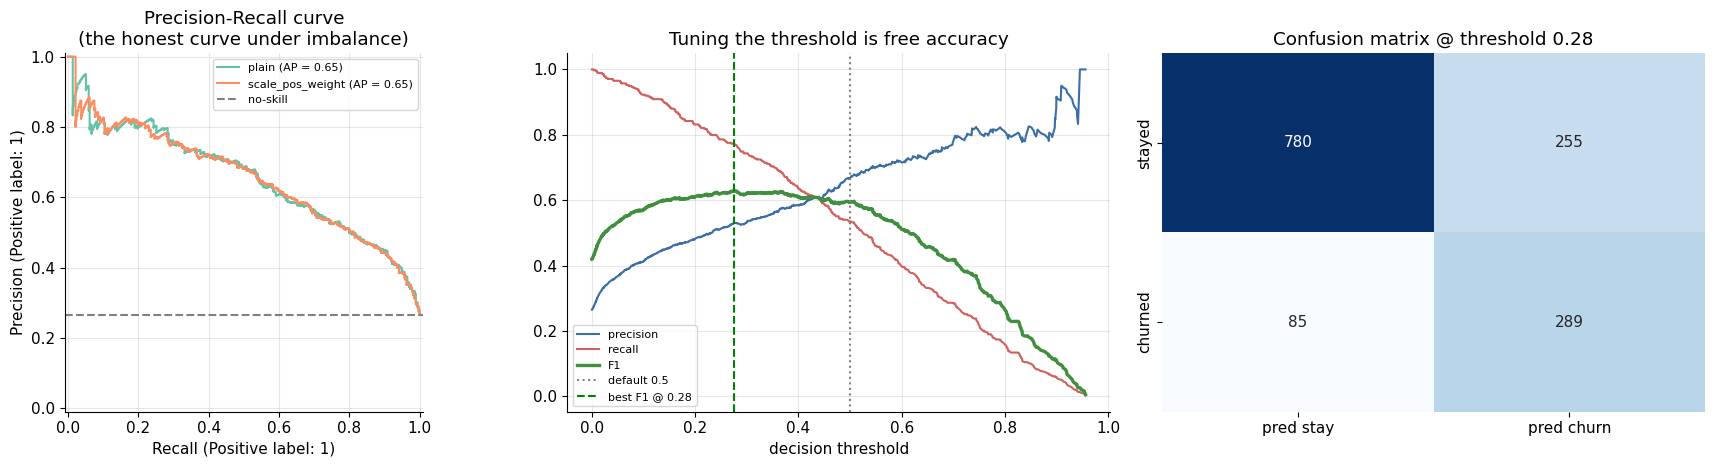

plain              thr=0.50  recall=0.535  precision=0.669  f1=0.594
plain              thr=0.28  recall=0.773  precision=0.531  f1=0.630
scale_pos_weight   thr=0.50  recall=0.762  precision=0.527  f1=0.623
scale_pos_weight   thr=0.28  recall=0.890  precision=0.443  f1=0.592


In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay

proba_plain = m_plain.predict_proba(X_te)[:, 1]
proba_spw   = m_spw.predict_proba(X_te)[:, 1]

prec, rec, thr = precision_recall_curve(y_te, proba_plain)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.nanargmax(f1s[:-1]))
best_thr = thr[best_i]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

PrecisionRecallDisplay.from_predictions(y_te, proba_plain, ax=axes[0], name="plain")
PrecisionRecallDisplay.from_predictions(y_te, proba_spw, ax=axes[0], name="scale_pos_weight")
axes[0].axhline(y_te.mean(), color="grey", ls="--", label="no-skill")
axes[0].set_title("Precision-Recall curve\n(the honest curve under imbalance)"); axes[0].legend(fontsize=8)

axes[1].plot(thr, prec[:-1], label="precision", color="#3b6ea5")
axes[1].plot(thr, rec[:-1], label="recall", color="#d1615d")
axes[1].plot(thr, f1s[:-1], label="F1", color="#3f8f3f", lw=2.4)
axes[1].axvline(0.5, color="grey", ls=":", label="default 0.5")
axes[1].axvline(best_thr, color="green", ls="--", label=f"best F1 @ {best_thr:.2f}")
axes[1].set_xlabel("decision threshold"); axes[1].set_title("Tuning the threshold is free accuracy")
axes[1].legend(fontsize=8)

for title, p, t in [("threshold 0.5", proba_plain, 0.5), (f"threshold {best_thr:.2f}", proba_plain, best_thr)]:
    pass
cm = confusion_matrix(y_te, (proba_plain >= best_thr).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2], cbar=False,
            xticklabels=["pred stay", "pred churn"], yticklabels=["stayed", "churned"])
axes[2].set_title(f"Confusion matrix @ threshold {best_thr:.2f}")
axes[2].grid(False)
plt.tight_layout(); plt.show()

for name, p in [("plain", proba_plain), ("scale_pos_weight", proba_spw)]:
    for t in [0.5, best_thr]:
        pr = (p >= t).astype(int)
        print(f"{name:<18} thr={t:.2f}  recall={recall_score(y_te, pr):.3f}  "
              f"precision={precision_score(y_te, pr):.3f}  f1={f1_score(y_te, pr):.3f}")

💡 **Takeaway 4:** `scale_pos_weight` and threshold tuning do *similar* things.
Pick **one**, tune it on validation data, and choose the operating point from the **business cost
matrix**, not from `argmax(F1)`. If a retained customer is worth ₹5,000 and an outreach costs ₹200,
that ratio — not the default 0.5 — defines your threshold.

---
# 10. Native categorical support & missing values

Since XGBoost 1.6/2.0 you can skip one-hot encoding entirely:

```python
X[col] = X[col].astype("category")
XGBClassifier(enable_categorical=True, tree_method="hist")
```

XGBoost then does **optimal partition splitting** on categories instead of a chain of binary
one-hot splits. Benefits: fewer columns, shallower trees, better handling of high-cardinality
features (think `pincode`, `product_id`).

In [ ]:
X_cat = X_t.copy()
for c in cat_cols:
    X_cat[c] = X_cat[c].astype("category")

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cat, y_t, test_size=0.2,
                                              random_state=RANDOM_STATE, stratify=y_t)

m_cat = XGBClassifier(**common, enable_categorical=True)
t0 = time.time(); m_cat.fit(Xc_tr, yc_tr); t_cat = time.time() - t0
p_cat = m_cat.predict_proba(Xc_te)[:, 1]

print(f"one-hot   : {X_ohe.shape[1]:>3} columns | AUC={RESULTS['XGB (no imbalance handling)']['roc_auc']:.4f} | {RESULTS['XGB (no imbalance handling)']['fit_s']:.2f}s")
print(f"native cat: {X_cat.shape[1]:>3} columns | AUC={roc_auc_score(yc_te, p_cat):.4f} | {t_cat:.2f}s")
RESULTS["XGB (native categorical)"] = {
    "accuracy": accuracy_score(yc_te, (p_cat >= .5).astype(int)),
    "roc_auc": roc_auc_score(yc_te, p_cat),
    "pr_auc": average_precision_score(yc_te, p_cat),
    "recall": recall_score(yc_te, (p_cat >= .5).astype(int)),
    "f1": f1_score(yc_te, (p_cat >= .5).astype(int)), "fit_s": t_cat}

one-hot   :  46 columns | AUC=0.8410 | 0.32s
native cat:  19 columns | AUC=0.8390 | 0.30s


### How missing values are handled
For each split, XGBoost tries sending all NaNs left and all NaNs right, and **keeps whichever
direction gives more gain**. The default direction is learned per node, from the data.

⚠️ This is powerful and dangerous: if missingness is *informative* (a blank `TotalCharges` means
"brand-new customer"), XGBoost exploits it — great. If missingness is an artefact of your data
pipeline that will not exist in production, the model has learned a **leak**. Always ask *why* a
value is missing before letting the model use it.

In [ ]:
# Demonstration: punch 20% NaNs into an informative column and watch XGBoost cope
X_hole = X_tr.copy(); X_hole_te = X_te.copy()
mask = np.random.default_rng(0).random(len(X_hole)) < 0.2
X_hole.loc[mask, "tenure"] = np.nan
mask_te = np.random.default_rng(1).random(len(X_hole_te)) < 0.2
X_hole_te.loc[mask_te, "tenure"] = np.nan

m_hole = XGBClassifier(**common).fit(X_hole, y_tr)
print(f"AUC with 20% of 'tenure' missing, NO imputation: "
      f"{roc_auc_score(y_te, m_hole.predict_proba(X_hole_te)[:, 1]):.4f}")
print(f"AUC on the clean data                          : {RESULTS['XGB (no imbalance handling)']['roc_auc']:.4f}")

AUC with 20% of 'tenure' missing, NO imputation: 0.8425
AUC on the clean data                          : 0.8410


---
# 11. Tuning properly

### 11.1 RandomizedSearchCV
Random search beats grid search when only a few parameters matter (which is almost always) —
you get more distinct values per parameter for the same budget.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

param_dist = {
    "max_depth":        randint(3, 9),
    "min_child_weight": randint(1, 20),
    "gamma":            uniform(0, 2),
    "subsample":        uniform(0.6, 0.4),      # 0.6 .. 1.0
    "colsample_bytree": uniform(0.5, 0.5),      # 0.5 .. 1.0
    "reg_lambda":       uniform(0, 20),
    "reg_alpha":        uniform(0, 2),
}

search = RandomizedSearchCV(
    XGBClassifier(n_estimators=400, learning_rate=0.05, eval_metric="logloss",
                  n_jobs=1, random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
t0 = time.time(); search.fit(X_tr, y_tr); print(f"search took {time.time()-t0:.1f}s")
print("\nBest CV AUC :", round(search.best_score_, 4))
print("Best params :"); print(json.dumps({k: round(v, 3) if isinstance(v, float) else v
                                          for k, v in search.best_params_.items()}, indent=2))

evaluate(search.best_estimator_, "XGBoost (tuned, 25 iters)")

search took 17.7s

Best CV AUC : 0.8501
Best params :
{
  "colsample_bytree": 0.52,
  "gamma": 1.421,
  "max_depth": 4,
  "min_child_weight": 10,
  "reg_alpha": 0.879,
  "reg_lambda": 4.034,
  "subsample": 0.958
}


XGBoost (tuned, 25 iters)          acc=0.8070  auc=0.8486  pr_auc=0.6635  recall=0.5321  0.22s


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.5202167947692157)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datas

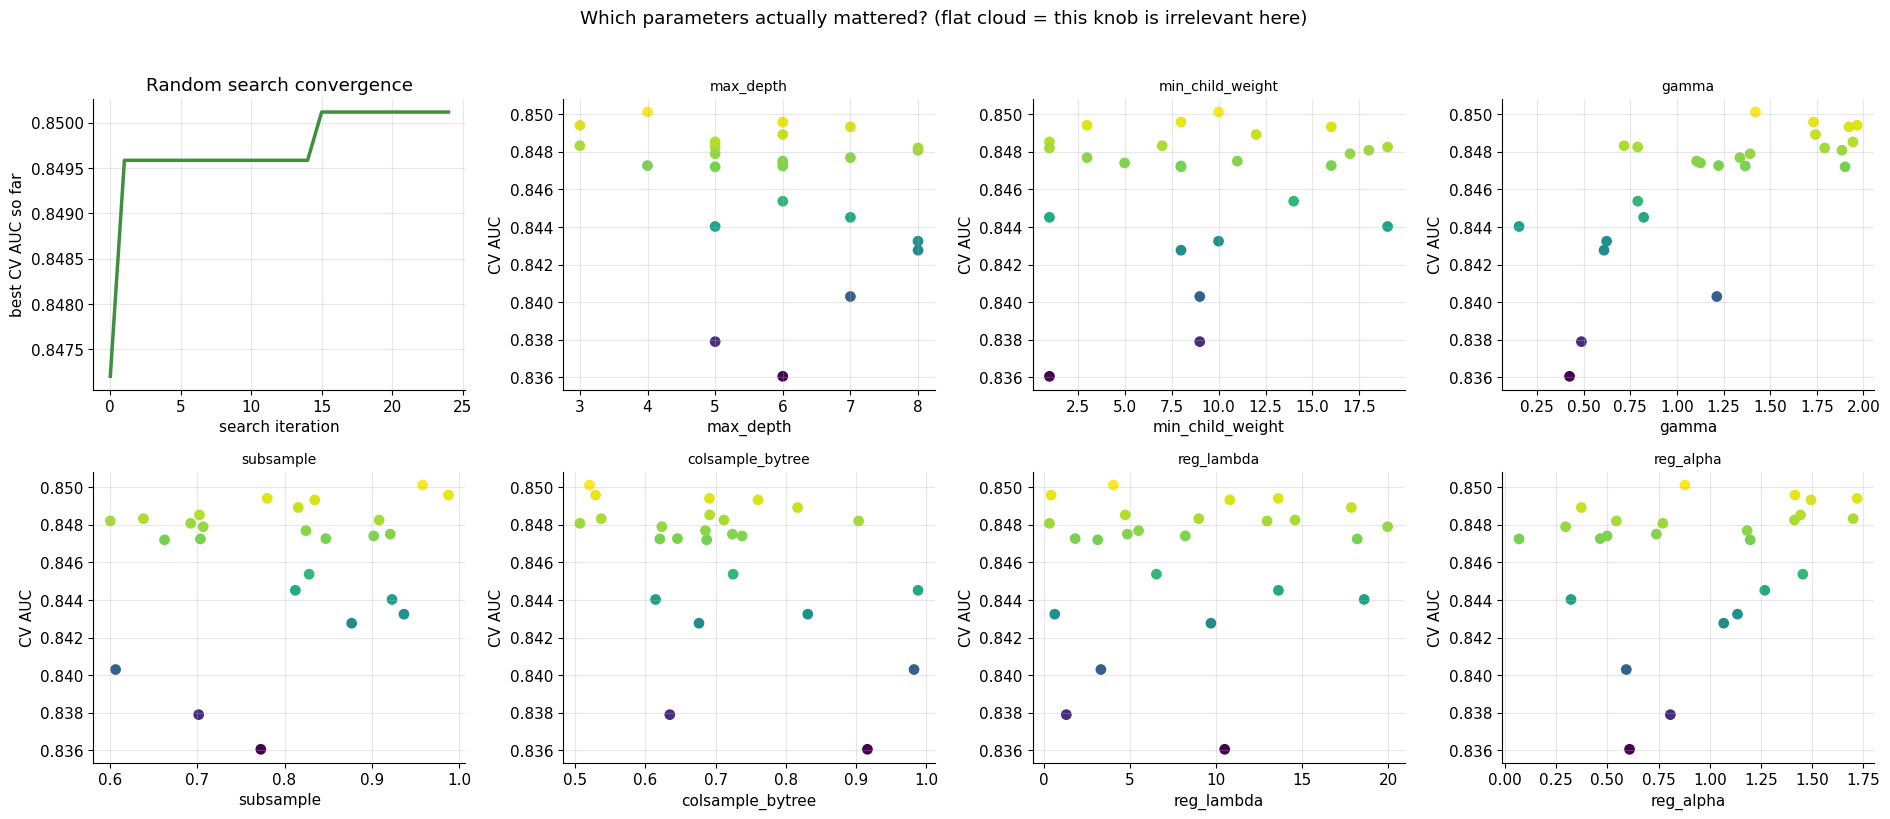

In [ ]:
res = pd.DataFrame(search.cv_results_)
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
axes = axes.ravel()
axes[0].plot(np.maximum.accumulate(res["mean_test_score"].values), lw=2.5, color="#3f8f3f")
axes[0].set_xlabel("search iteration"); axes[0].set_ylabel("best CV AUC so far")
axes[0].set_title("Random search convergence")

for ax, p in zip(axes[1:], param_dist.keys()):
    ax.scatter(res["param_" + p].astype(float), res["mean_test_score"], s=45,
               c=res["mean_test_score"], cmap="viridis")
    ax.set_xlabel(p); ax.set_ylabel("CV AUC"); ax.set_title(p, fontsize=10)
plt.suptitle("Which parameters actually mattered? (flat cloud = this knob is irrelevant here)", y=1.02)
plt.tight_layout(); plt.show()

### 11.2 The native API and `xgb.cv`
`xgb.cv` gives you the **cross-validated learning curve** — the cleanest way to pick `n_estimators`
without carving out a separate validation set.

CV picked 64 rounds | mean test AUC = 0.8498 (+/- 0.0042)


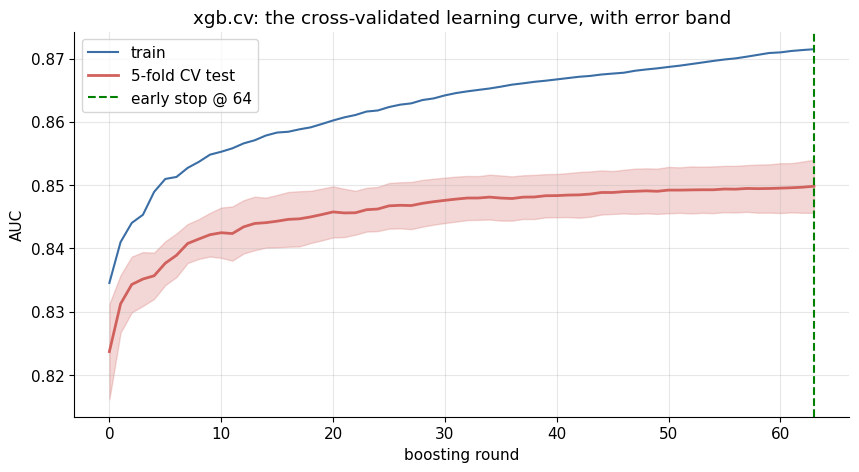

Native-API test AUC: 0.8489


In [ ]:
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dtest  = xgb.DMatrix(X_te, label=y_te)

params = {"objective": "binary:logistic", "eval_metric": "auc", "eta": 0.05,
          "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8,
          "min_child_weight": 5, "lambda": 5, "nthread": -1, "seed": RANDOM_STATE}

cv_res = xgb.cv(params, dtrain, num_boost_round=1200, nfold=5,
                early_stopping_rounds=50, verbose_eval=False, seed=RANDOM_STATE)

best_rounds = len(cv_res)
print(f"CV picked {best_rounds} rounds | mean test AUC = {cv_res['test-auc-mean'].iloc[-1]:.4f} "
      f"(+/- {cv_res['test-auc-std'].iloc[-1]:.4f})")

plt.figure(figsize=(10, 5))
plt.plot(cv_res["train-auc-mean"], label="train", color="#3b6ea5")
plt.fill_between(cv_res.index, cv_res["test-auc-mean"] - cv_res["test-auc-std"],
                 cv_res["test-auc-mean"] + cv_res["test-auc-std"], alpha=0.25, color="#d1615d")
plt.plot(cv_res["test-auc-mean"], label="5-fold CV test", color="#d1615d", lw=2)
plt.axvline(best_rounds - 1, color="green", ls="--", label=f"early stop @ {best_rounds}")
plt.xlabel("boosting round"); plt.ylabel("AUC")
plt.title("xgb.cv: the cross-validated learning curve, with error band")
plt.legend(); plt.show()

booster = xgb.train(params, dtrain, num_boost_round=best_rounds)
print("Native-API test AUC:", round(roc_auc_score(y_te, booster.predict(dtest)), 4))

---
# 12. Interpretation

## 12.1 Three different "importances" — they disagree, and that is the point

| `importance_type` | Meaning | Use when |
|---|---|---|
| **`gain`** | average loss reduction from splits on this feature | **the default answer to "what matters?"** ✅ |
| `weight` | how many times the feature was used to split | biased toward high-cardinality / continuous features |
| `cover` | average number of samples touched by those splits | how *broadly* a feature acts |

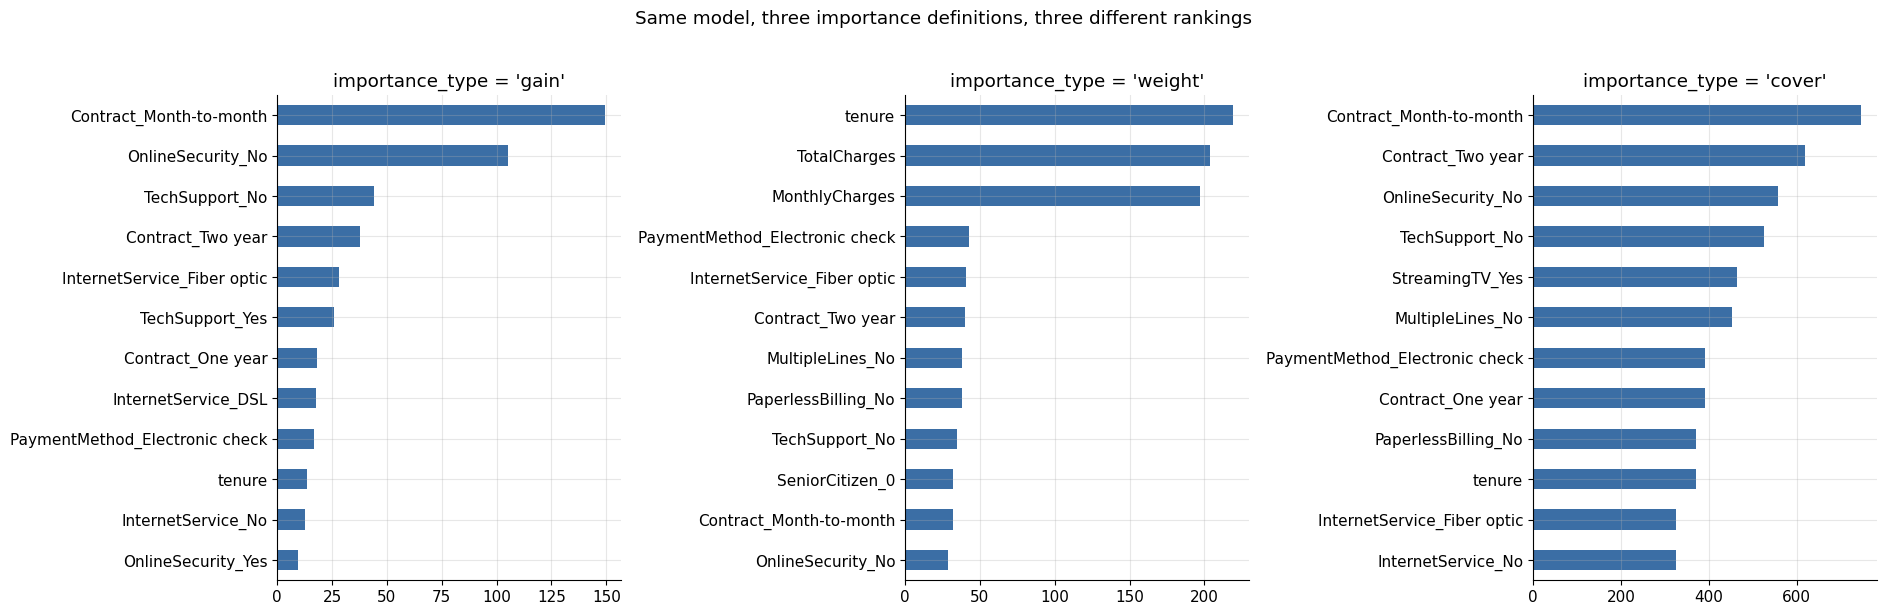

In [ ]:
best_model = search.best_estimator_
bst = best_model.get_booster()

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, itype in zip(axes, ["gain", "weight", "cover"]):
    scores = pd.Series(bst.get_score(importance_type=itype)).sort_values(ascending=False).head(12)
    scores[::-1].plot(kind="barh", ax=ax, color="#3b6ea5")
    ax.set_title(f"importance_type = '{itype}'")
plt.suptitle("Same model, three importance definitions, three different rankings", y=1.02)
plt.tight_layout(); plt.show()

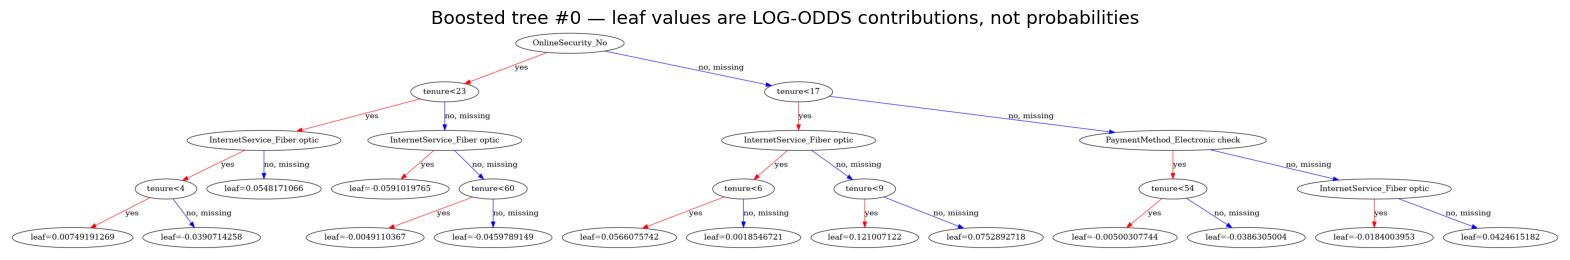

In [ ]:
# Plot an actual tree (needs graphviz; skipped gracefully if unavailable)
try:
    fig, ax = plt.subplots(figsize=(20, 7))
    xgb.plot_tree(best_model, num_trees=0, ax=ax)
    ax.grid(False); ax.set_title("Boosted tree #0 — leaf values are LOG-ODDS contributions, not probabilities")
    plt.show()
except Exception as e:
    print("graphviz not available, skipping tree plot:", type(e).__name__)
    print("In Colab you can run:  !pip install graphviz  &&  !apt-get -qq install graphviz")
    # text fallback - always works
    print("\nFirst tree as text:\n")
    print(bst.get_dump()[0][:1200])

## 12.2 SHAP — the one that actually answers "why this customer?"

Global importances tell you what matters *on average*. SHAP values decompose **each individual
prediction** into per-feature contributions with a solid game-theoretic guarantee:

$$\hat{y}_i = \underbrace{\phi_0}_{\text{base value}} + \sum_j \phi_{ij}$$

`TreeSHAP` computes these exactly for tree ensembles in polynomial time — this is *the* standard
way to explain a boosted model to a stakeholder or a regulator.

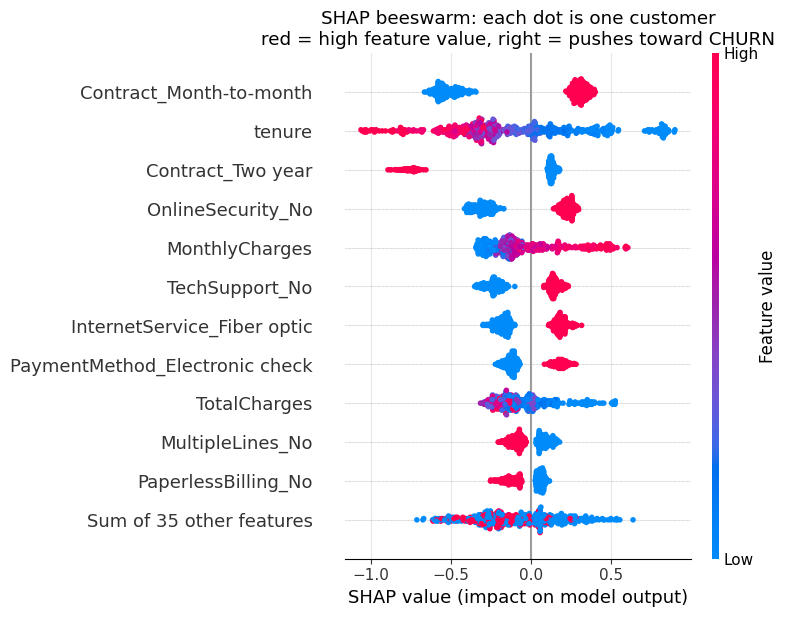

In [ ]:
try:
    import shap
except ImportError:
    !pip install -q shap
    import shap

explainer = shap.TreeExplainer(best_model)
X_sample = X_te.iloc[:500]
sv = explainer(X_sample)

shap.plots.beeswarm(sv, max_display=12, show=False)
plt.title("SHAP beeswarm: each dot is one customer\nred = high feature value, right = pushes toward CHURN")
plt.tight_layout(); plt.show()

Customer #38: predicted churn probability = 86.6%


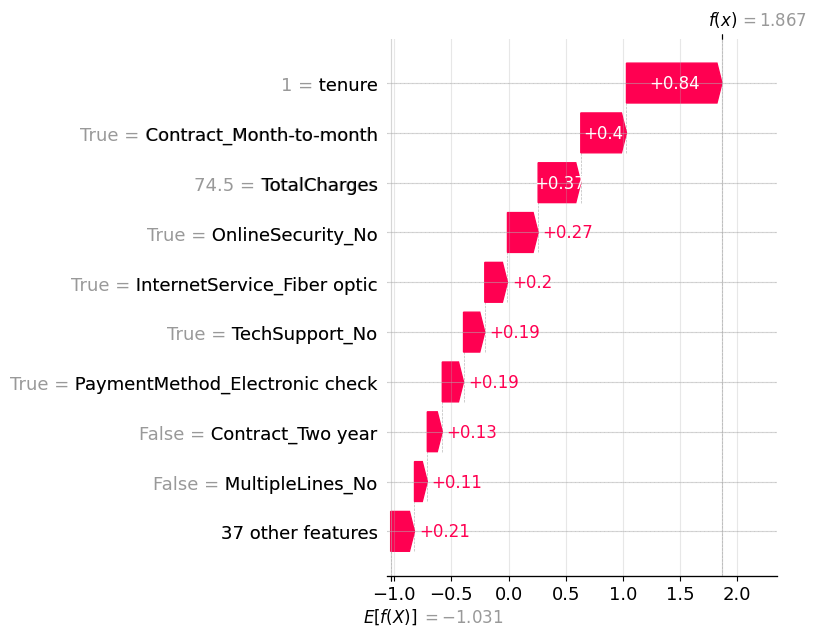

In [ ]:
# Explain ONE customer - this is what you put in front of a business user
i = int(np.argmax(best_model.predict_proba(X_sample)[:, 1]))   # the most at-risk customer
print(f"Customer #{i}: predicted churn probability = {best_model.predict_proba(X_sample)[i, 1]:.1%}")
shap.plots.waterfall(sv[i], max_display=10, show=False)
plt.tight_layout(); plt.show()

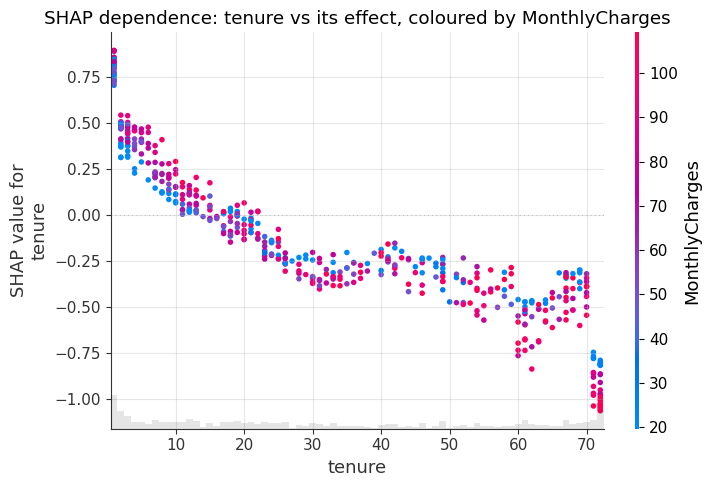

In [ ]:
# Dependence plot: how does one feature drive the prediction, and what does it interact with?
shap.plots.scatter(sv[:, "tenure"], color=sv[:, "MonthlyCharges"], show=False)
plt.title("SHAP dependence: tenure vs its effect, coloured by MonthlyCharges")
plt.tight_layout(); plt.show()

---
# 13. Regression + a speed benchmark

Same algorithm, different objective. We predict **wine quality** (a 0–10 score) from 11
physico-chemical measurements — *Wine Quality (red)*, UCI ML Repository.

In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

WINE = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"
wine = pd.read_csv(WINE)
print(wine.shape); print(wine.columns.tolist())

Xw = wine.drop(columns="quality"); yw = wine["quality"].astype(float)
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, test_size=0.2, random_state=RANDOM_STATE)

regressors = {
    "Random Forest":      RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE),
    "sklearn GBM":        GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                    max_depth=4, random_state=RANDOM_STATE),
    "XGBoost":            XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                                       subsample=0.8, colsample_bytree=0.8, reg_lambda=2,
                                       objective="reg:squarederror", n_jobs=-1,
                                       random_state=RANDOM_STATE),
}
rows = {}
for name, m in regressors.items():
    t0 = time.time(); m.fit(Xw_tr, yw_tr); secs = time.time() - t0
    pred = m.predict(Xw_te)
    rows[name] = {"RMSE": np.sqrt(mean_squared_error(yw_te, pred)),
                  "R2": r2_score(yw_te, pred), "seconds": secs}
    print(f"{name:<16} RMSE={rows[name]['RMSE']:.4f}  R2={rows[name]['R2']:.4f}  {secs:.2f}s")
reg_df = pd.DataFrame(rows).T

(1599, 12)
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


Random Forest    RMSE=0.5544  R2=0.5297  2.08s


sklearn GBM      RMSE=0.5976  R2=0.4536  1.14s
XGBoost          RMSE=0.5720  R2=0.4994  0.18s


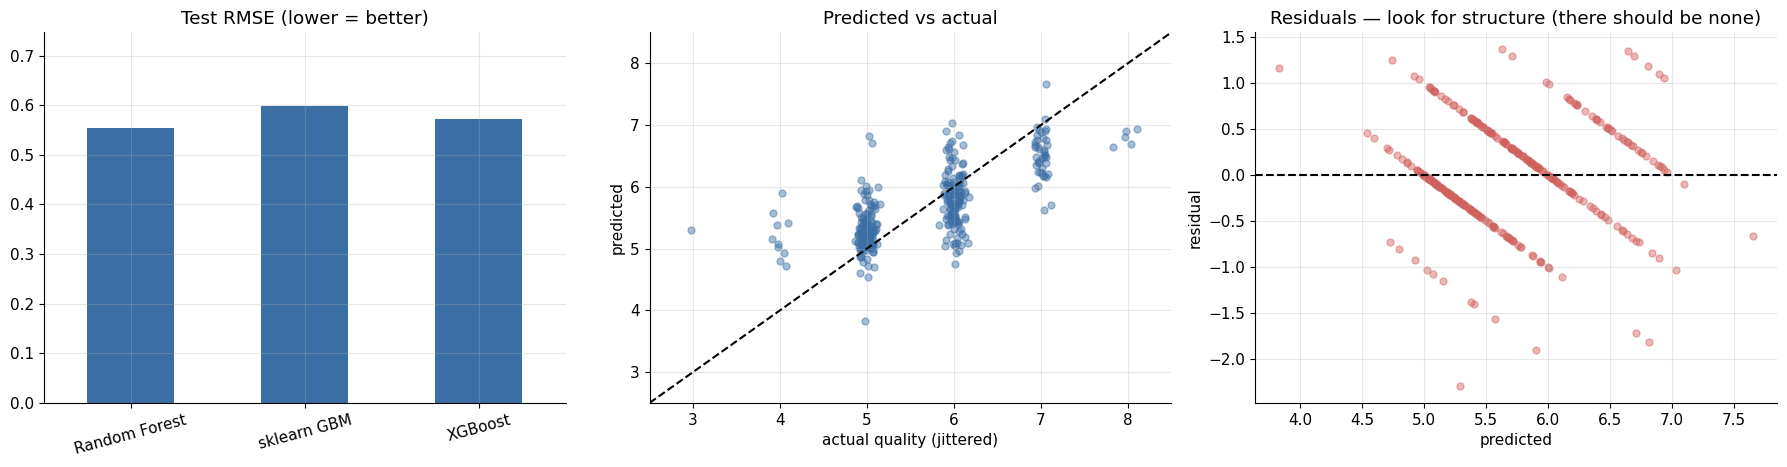

In [ ]:
xgbr = regressors["XGBoost"]; pred = xgbr.predict(Xw_te)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
reg_df["RMSE"].plot(kind="bar", ax=axes[0], color="#3b6ea5", rot=15)
axes[0].set_title("Test RMSE (lower = better)"); axes[0].set_ylim(0, reg_df["RMSE"].max()*1.25)

axes[1].scatter(yw_te + np.random.normal(0, .06, len(yw_te)), pred, alpha=0.45, s=25, color="#3b6ea5")
lims = [yw_te.min()-.5, yw_te.max()+.5]
axes[1].plot(lims, lims, "k--"); axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel("actual quality (jittered)"); axes[1].set_ylabel("predicted")
axes[1].set_title("Predicted vs actual")

axes[2].scatter(pred, yw_te - pred, alpha=0.45, s=25, color="#d1615d")
axes[2].axhline(0, color="k", ls="--")
axes[2].set_xlabel("predicted"); axes[2].set_ylabel("residual")
axes[2].set_title("Residuals — look for structure (there should be none)")
plt.tight_layout(); plt.show()

tree_method=exact    32.98s   train AUC=0.9996


tree_method=approx   22.72s   train AUC=0.9998


tree_method=hist      1.95s   train AUC=0.9999


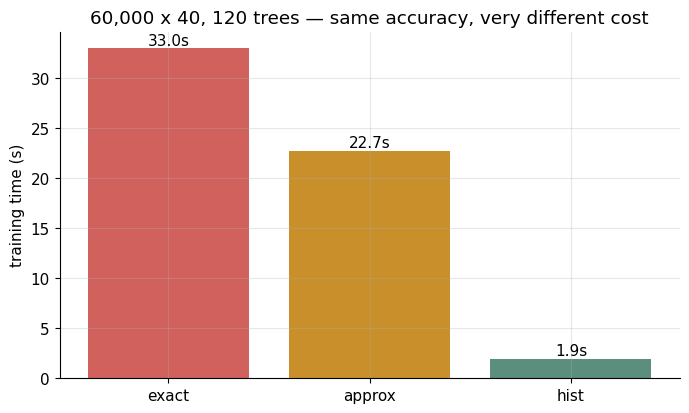

In [ ]:
# 🧪 Why 'hist' replaced the exact greedy algorithm: a speed benchmark
from sklearn.datasets import make_classification

Xb, yb = make_classification(n_samples=60000, n_features=40, n_informative=15,
                             random_state=RANDOM_STATE)
timings = {}
for method in ["exact", "approx", "hist"]:
    m = XGBClassifier(n_estimators=120, max_depth=6, tree_method=method,
                      eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
    t0 = time.time(); m.fit(Xb, yb); secs = time.time() - t0
    auc = roc_auc_score(yb, m.predict_proba(Xb)[:, 1])
    timings[method] = {"seconds": secs, "train_auc": auc}
    print(f"tree_method={method:<7} {secs:6.2f}s   train AUC={auc:.4f}")

t = pd.DataFrame(timings).T
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(t.index, t["seconds"], color=["#d1615d", "#c98f2b", "#5b8e7d"])
for i, v in enumerate(t["seconds"]): ax.text(i, v, f"{v:.1f}s", ha="center", va="bottom")
ax.set_ylabel("training time (s)")
ax.set_title("60,000 x 40, 120 trees — same accuracy, very different cost")
plt.show()

---
# 14. Ecosystem, deployment, pitfalls

## 14.1 XGBoost vs LightGBM vs CatBoost

| | **XGBoost** | **LightGBM** | **CatBoost** |
|---|---|---|---|
| Tree growth | level-wise (depth-first balanced) | **leaf-wise** (best-first) | **symmetric / oblivious** trees |
| Speed on wide data | fast | **fastest** | fast |
| Small datasets | solid | can overfit (leaf-wise) | **most robust** |
| Categorical features | native (1.6+) | native | **best-in-class** (ordered target statistics) |
| Overfitting tendency | medium | higher — cap `num_leaves` | lowest (ordered boosting) |
| Inference speed | fast | fast | **fastest** (oblivious trees vectorise) |
| Default hyper-params | need tuning | need tuning | **usually good out of the box** |

**Practical advice:** try XGBoost first (best documented, most stable API). Reach for LightGBM when
rows are in the millions, and CatBoost when you have many high-cardinality categorical columns or
little time to tune. On most tabular problems the three land within ~1% of each other — *feature
engineering moves the needle far more than the library choice.*

⚠️ And keep this in mind: on **small, clean, mostly-linear** problems, regularised logistic/linear
regression is sometimes as good and infinitely easier to defend. On **images, audio and text**,
use deep learning. Boosting owns **medium-sized tabular data**, which is most of the work in industry.

## 14.2 Saving and loading — do it right

In [ ]:
# ✅ Use the JSON/UBJ format - it is version-portable and human-readable.
#    ❌ pickle ties the file to the exact Python + library versions you had that day.
best_model.save_model("churn_xgb.json")

reloaded = XGBClassifier()
reloaded.load_model("churn_xgb.json")

same = np.allclose(best_model.predict_proba(X_te)[:, 1], reloaded.predict_proba(X_te)[:, 1])
print("Reloaded model gives identical predictions:", same)

# Scoring one new customer end to end
one = X_te.iloc[[0]]
p = reloaded.predict_proba(one)[0, 1]
print(f"\nCustomer churn probability: {p:.1%}  ->  action: "
      f"{'RETENTION CALL' if p >= best_thr else 'no action'} (threshold {best_thr:.2f})")

print("\nModel file size:", round(len(open('churn_xgb.json','rb').read())/1024, 1), "KB")

Reloaded model gives identical predictions: True

Customer churn probability: 3.5%  ->  action: no action (threshold 0.28)

Model file size: 307.2 KB


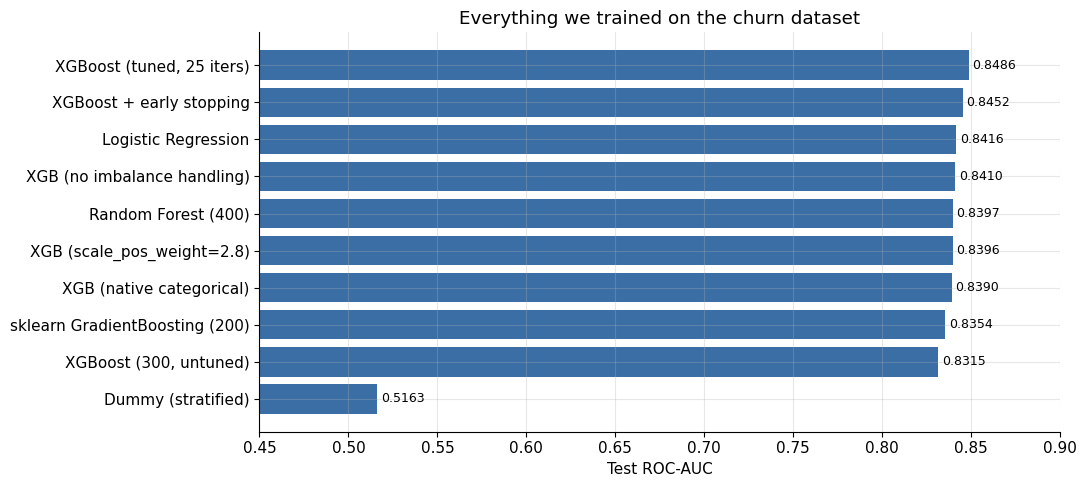

,accuracy,roc_auc,pr_auc,recall,f1,fit_s
"XGBoost (tuned, 25 iters)",0.8070,0.8486,0.6635,0.5321,0.5940,0.2247
XGBoost + early stopping,0.7977,0.8452,0.6539,0.4519,0.5425,0.2136
Logistic Regression,0.8070,0.8416,0.6311,0.5668,0.6092,0.2050
XGB (no imbalance handling),0.8062,0.8410,0.6548,0.5348,0.5944,0.3245
Random Forest (400),0.7970,0.8397,0.6470,0.5053,0.5693,2.1316
XGB (scale_pos_weight=2.8),0.7551,0.8396,0.6532,0.7620,0.6230,0.3252
XGB (native categorical),0.8013,0.8390,0.6547,0.5374,0.5894,0.2994
sklearn GradientBoosting (200),0.7885,0.8354,0.6481,0.5027,0.5579,1.9496
"XGBoost (300, untuned)",0.7949,0.8315,0.6336,0.5401,0.5830,0.3236
Dummy (stratified),0.6217,0.5163,0.2723,0.2914,0.2903,0.0014


In [ ]:
final = pd.DataFrame(RESULTS).T.sort_values("roc_auc", ascending=False).round(4)
fig, ax = plt.subplots(figsize=(11, 5))
f = final.sort_values("roc_auc")
ax.barh(f.index, f["roc_auc"], color="#3b6ea5")
ax.set_xlim(0.45, 0.90); ax.set_xlabel("Test ROC-AUC")
ax.set_title("Everything we trained on the churn dataset")
for i, v in enumerate(f["roc_auc"]): ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()
final

## 14.3 ⚠️ Pitfalls that bite people in production

1. **Early stopping on the test set.** It is model selection. Use a third split, or `xgb.cv`.
2. **Target leakage.** If XGBoost hands you 0.99 AUC on a real business problem, you have a leak.
   Find the feature that would not exist at prediction time. It is almost always there.
3. **Random K-fold on time-series data.** Use `TimeSeriesSplit` — otherwise you train on the future.
4. **Tuning `n_estimators` with grid search.** Wasteful. Fix a low learning rate and early-stop.
5. **Trusting `weight` importance.** Use `gain`, or better, SHAP.
6. **Forgetting `scale_pos_weight` changes probability calibration.** If you need *calibrated
   probabilities* (for expected-value decisions), leave it at 1 and tune the threshold instead,
   or calibrate afterwards with `CalibratedClassifierCV`.
7. **Category dtype mismatch at inference.** With `enable_categorical`, the serving data must use
   the **same category dtype and the same category list** as training. Persist it.
8. **Extrapolation.** Trees cannot extrapolate beyond the range they saw. A boosted model will
   predict a flat line outside the training domain — never use it for trend forecasting without care.

---
# 15. Exercises

1. **Break early stopping.** Set `early_stopping_rounds=5` in Section 7. Does it stop too soon?
   Now set it to 200. What is the cost of each mistake?
2. **Learning rate vs rounds.** Re-run Section 7 with `learning_rate=0.3` and `0.01`.
   Record `best_iteration` and the final test AUC for each. Plot the trade-off.
3. **The min_child_weight / gamma / reg_lambda triangle.** Pick the best `max_depth=8` model
   (which overfits) and try to fix it using *only* those three parameters. How close to the
   `max_depth=4` validation AUC can you get?
4. **Cost-sensitive threshold.** Assume a retained customer is worth ₹5,000 and an outreach costs ₹200.
   Write a function that computes expected profit for every threshold and pick the maximum.
   How far is it from the F1-optimal threshold?
5. **Custom objective.** Implement a weighted log-loss where false negatives cost 3× false positives,
   pass it as `obj=` to `xgb.train`, and compare with `scale_pos_weight=3`.
6. **Beat the tuned model.** Add engineered features to the churn data — e.g.
   `TotalCharges / (tenure+1)`, a count of subscribed services, `MonthlyCharges` percentile.
   Feature engineering usually beats another 100 rounds of hyper-parameter search. Prove it.
7. **Try LightGBM.** `!pip install lightgbm`, run `LGBMClassifier` with the same split, compare
   AUC and training time.

---
## Further reading
- Friedman (2001), *Greedy Function Approximation: A Gradient Boosting Machine* — the original paper
- Chen & Guestrin (2016), *XGBoost: A Scalable Tree Boosting System* — https://arxiv.org/abs/1603.02754
- XGBoost docs — https://xgboost.readthedocs.io (start with *Introduction to Boosted Trees*)
- XGBoost parameter reference — https://xgboost.readthedocs.io/en/stable/parameter.html
- Lundberg & Lee (2017), *A Unified Approach to Interpreting Model Predictions* (SHAP)
- Grinsztajn et al. (2022), *Why do tree-based models still outperform deep learning on tabular data?*

### 🎓 What you should be able to do now
- Explain boosting as gradient descent in function space, and code it in 9 lines
- Choose between bagging and boosting for a given problem, and justify it with bias/variance
- Train, early-stop, tune, and interpret an XGBoost model on messy real data
- Pick the right metric and the right decision threshold for an imbalanced business problem
- Name the failure modes before they reach production